<a href="https://colab.research.google.com/github/amaldevk/diabetes_progression_ANN/blob/main/diabetes_progression_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler

In [2]:
diabetes_data = load_diabetes(as_frame=True)

In [4]:
X = diabetes_data.data
y = diabetes_data.target

In [5]:
X.isnull().sum()

,0
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [8]:
X_scaled.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.800500,1.065488,1.297088,0.459841,-0.929746,-0.732065,-0.912451,-0.054499,0.418531,-0.370989
1,-0.039567,-0.938537,-1.082180,-0.553505,-0.177624,-0.402886,1.564414,-0.830301,-1.436589,-1.938479
2,1.793307,1.065488,0.934533,-0.119214,-0.958674,-0.718897,-0.680245,-0.054499,0.060156,-0.545154
3,-1.872441,-0.938537,-0.243771,-0.770650,0.256292,0.525397,-0.757647,0.721302,0.476983,-0.196823
4,0.113172,-0.938537,-0.764944,0.459841,0.082726,0.327890,0.171178,-0.054499,-0.672502,-0.980568


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
dataset_df = X.copy()
dataset_df['Target'] = y

In [11]:
dataset_df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


Text(0.5, 0, 'Progression Value')

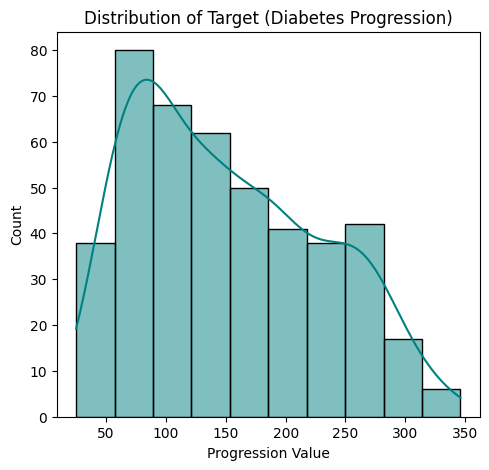

In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(y, kde=True, color='teal')
plt.title("Distribution of Target (Diabetes Progression)")
plt.xlabel("Progression Value")

/tmp/ipykernel_11721/820697610.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, palette='viridis')


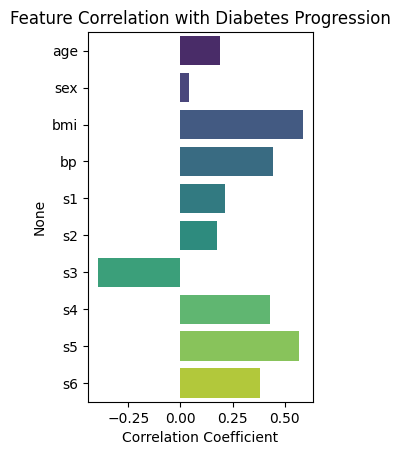

In [15]:
plt.subplot(1, 2, 2)
correlations = dataset_df.corr()['Target'].drop('Target')
sns.barplot(x=correlations.values, y=correlations.index, palette='viridis')
plt.title("Feature Correlation with Diabetes Progression")
plt.xlabel("Correlation Coefficient")

plt.show()

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split

In [17]:
tf.random.set_seed(42)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [19]:
model_baseline = Sequential([Dense(16, activation='relu', input_shape=(X_train.shape[1],)),Dense(1, activation='linear')])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model_baseline.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_squared_error']
)

In [21]:
history_baseline = model_baseline.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 31633.7656 - mean_squared_error: 31633.7656 - val_loss: 22520.3477 - val_mean_squared_error: 22520.3477
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 31542.9863 - mean_squared_error: 31542.9863 - val_loss: 22459.1113 - val_mean_squared_error: 22459.1113
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 31454.4355 - mean_squared_error: 31454.4355 - val_loss: 22397.6406 - val_mean_squared_error: 22397.6406
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 31366.7988 - mean_squared_error: 31366.7988 - val_loss: 22335.2324 - val_mean_squared_error: 22335.2324
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 31277.8945 - mean_squared_error: 31277.8945 - val_loss: 22270.7441 - val_mean_squared_error: 22270.7441
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 31185.6992 - mean_squared_error: 31185.6992 - val_loss: 22203.5840 - val_mean_squared_error: 22203.5840
Epoch 7/100
18/18 ━━━

In [23]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred_baseline = model_baseline.predict(X_test)

mse_baseline = mean_squared_error(y_test, y_pred_baseline)
r2_baseline = r2_score(y_test, y_pred_baseline)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [24]:
print(f"Mean Squared Error (MSE): {mse_baseline:.2f}")
print(f"R² Score                : {r2_baseline:.4f}")

Mean Squared Error (MSE): 6508.38
R² Score                : -0.2284


In [25]:
from tensorflow.keras.layers import Dropout, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [26]:
model_improved = Sequential([
    Dense(64, input_shape=(X_train.shape[1],)),
    LeakyReLU(alpha=0.1),
    Dropout(0.2),
    Dense(32),
    LeakyReLU(alpha=0.1),
    Dense(1, activation='linear')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [27]:
model_improved.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='mean_squared_error',
    metrics=['mean_squared_error']
)

In [28]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=0.0001
)

In [29]:
history_improved = model_improved.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=16,
    callbacks=[lr_scheduler],
)

Epoch 1/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 28191.8535 - mean_squared_error: 28191.8535 - val_loss: 15164.8730 - val_mean_squared_error: 15164.8730 - learning_rate: 0.0100
Epoch 2/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 10940.0000 - mean_squared_error: 10940.0000 - val_loss: 3864.5679 - val_mean_squared_error: 3864.5679 - learning_rate: 0.0100
Epoch 3/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4789.0864 - mean_squared_error: 4789.0864 - val_loss: 3410.6943 - val_mean_squared_error: 3410.6943 - learning_rate: 0.0100
Epoch 4/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3709.4680 - mean_squared_error: 3709.4680 - val_loss: 2955.8096 - val_mean_squared_error: 2955.8096 - learning_rate: 0.0100
Epoch 5/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3314.3401 - mean_squared_error: 3314.3401 - val_loss: 2874.6792 - val_mean_squared_error: 2874.6792 - learning_rate: 0.0100
Epoch 6/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3357.9160 - mean_sq



*   Added a 2nd hidden layer so the model can learn complex feature interactions.
*   Switched to LeakyReLU to stop neurons from "dying" during training and keep all layers actively learning.
*   Turned off 20% of neurons randomly during training to stop overfitting.
*   Dynamically lowered the learning rate to fine-tune model weights smoothly.





In [30]:
y_pred_improved = model_improved.predict(X_test)
mse_improved = mean_squared_error(y_test, y_pred_improved)
r2_improved = r2_score(y_test, y_pred_improved)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


In [31]:
print(f"Improved MSE : {mse_improved:.2f}")
print(f"Improved R²  : {r2_improved:.4f}")

Improved MSE : 2694.03
Improved R²  : 0.4915


In [32]:
comparison_df = pd.DataFrame({
    'Metric': ['Mean Squared Error (MSE)', 'R² Score'],
    'Baseline Model': [round(mse_baseline, 2), round(r2_baseline, 4)],
    'Improved Model': [round(mse_improved, 2), round(r2_improved, 4)]
})

In [33]:
comparison_df

,Metric,Baseline Model,Improved Model
0,Mean Squared Error (MSE),6508.3800,2694.0300
1,R² Score,-0.2284,0.4915


The baseline model obtained a negative R² score, indicating that its predictions performed worse than a simple mean-based baseline on the test set. The improved ANN achieved lower MSE and a higher R² score than the baseline model on the test set